<a href="https://colab.research.google.com/github/kanimozhibalakrishnan/Predicting-Performance-of-the-Instructor/blob/main/PerformancePredition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

from google.colab import files
uploaded = files.upload()

# Load your dataset (replace 'filename.csv' with the actual file path)
data = pd.read_csv('instructorpredict.csv')

Saving instructorpredict.csv to instructorpredict.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Define the target variable and features
data['performance'] = (data['avg_review'] > 3).astype(int)
X = data.drop(columns=["avg_review", "performance"])
y = data['performance']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred_train = rf_classifier.predict(X_train)
y_pred_test = rf_classifier.predict(X_test)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

print(f"Train Accuracy: {accuracy_train}")
print(f"Test Accuracy: {accuracy_test}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


KeyError: 'avg_review'

Train Accuracy: 0.998926116838488
Test Accuracy: 0.9261168384879725
Confusion Matrix:
[[533  57]
 [ 29 545]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       590
           1       0.91      0.95      0.93       574

    accuracy                           0.93      1164
   macro avg       0.93      0.93      0.93      1164
weighted avg       0.93      0.93      0.93      1164



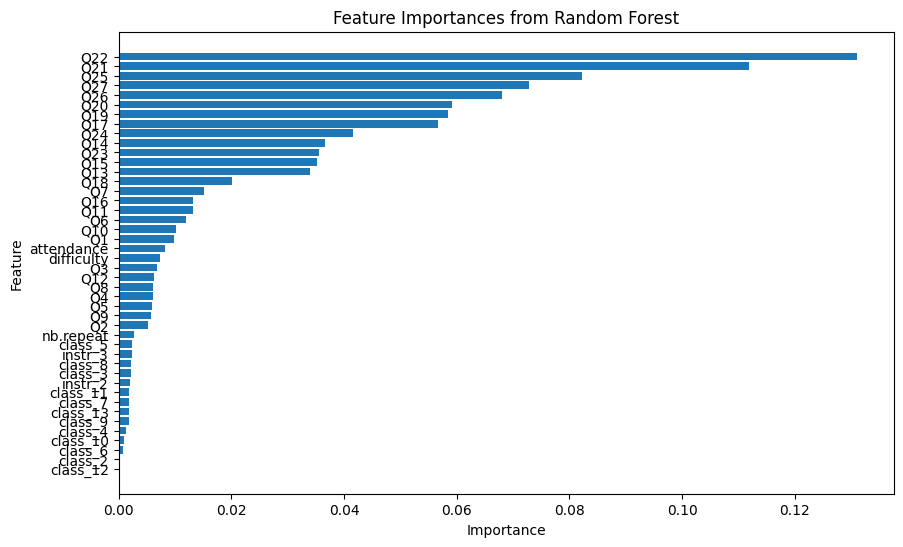

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Load the dataset
#data = pd.read_csv('instructor_evaluations.csv')

# Create the target variable 'performance': 1 for Good (avg review > 3), 0 for Bad (avg review <= 3)
data['performance'] = (data['avg review'] > 3).astype(int)

# Define the features (X) and the target variable (y)
X = data.drop(columns=["avg review", "performance"])
y = data['performance']

# Encode categorical columns if any (assuming 'instructor', 'class' are categorical)
X = pd.get_dummies(X, columns=['instr', 'class'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions on the training and testing sets
y_pred_train = rf_classifier.predict(X_train)
y_pred_test = rf_classifier.predict(X_test)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

print(f"Train Accuracy: {accuracy_train}")
print(f"Test Accuracy: {accuracy_test}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Visualize the feature importances
importances = rf_classifier.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# Making a prediction on new data
new_data = pd.DataFrame({
    'instr': [2],
    'class': [1],
    'nb_repeat': [0],
    'attendance': [3],
    'difficulty': [2],
    'Q1': [4],
    'Q2': [4],
    'Q3': [4],
    # Add all other questions Q4-Q28 with appropriate values
    'Q4': [4],
    'Q5': [4],
    'Q6': [4],
    'Q7': [4],
    'Q8': [4],
    'Q9': [4],
    'Q10': [4],
    'Q11': [4],
    'Q12': [4],
    'Q13': [4],
    'Q14': [4],
    'Q15': [4],
    'Q16': [4],
    'Q17': [4],
    'Q18': [4],
    'Q19': [4],
    'Q20': [4],
    'Q21': [4],
    'Q22': [4],
    'Q23': [4],
    'Q24': [4],
    'Q25': [4],
    'Q26': [4],
    'Q27': [4],
    'Q28': [4]
})

# Ensure the new data has the same feature names and order
new_data_scaled = scaler.transform(new_data)
prediction = rf_classifier.predict(new_data_scaled)
performance = 'Good' if prediction[0] == 1 else 'Bad'

print(f"Predicted performance: {performance}")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Q28
- class
- instr
- nb_repeat
Feature names seen at fit time, yet now missing:
- class_10
- class_11
- class_12
- class_13
- class_2
- ...


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



# Define the target variable
data['performance'] = (data['avg review'] > 3).astype(int)

# Features and target
X = data.drop(columns=['avg review', 'performance'])
y = data['performance']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = rf_classifier.predict(X_train_scaled)
y_pred_test = rf_classifier.predict(X_test_scaled)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

print(f"Train Accuracy: {accuracy_train}")
print(f"Test Accuracy: {accuracy_test}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Making a prediction on new data
new_data = pd.DataFrame({
    'instr': [2],
    'class': [1],
    'nb.repeat': [0],
    'attendance': [3],
    'difficulty': [2],
    'Q1': [4],
    'Q2': [4],
    'Q3': [4],
    # Add all other questions Q4-Q28 with appropriate values
    'Q4': [4],
    'Q5': [4],
    'Q6': [4],
    'Q7': [4],
    'Q8': [4],
    'Q9': [4],
    'Q10': [4],
    'Q11': [4],
    'Q12': [4],
    'Q13': [4],
    'Q14': [4],
    'Q15': [4],
    'Q16': [4],
    'Q17': [4],
    'Q18': [4],
    'Q19': [4],
    'Q20': [4],
    'Q21': [4],
    'Q22': [4],
    'Q23': [4],
    'Q24': [4],
    'Q25': [4],
    'Q26': [4],
    'Q27': [4]
})

# Ensure the new data has the same feature names and order
new_data_scaled = scaler.transform(new_data)
prediction = rf_classifier.predict(new_data_scaled)
performance = 'Good' if prediction[0] == 1 else 'Bad'

print(f"Predicted performance: {performance}")


Train Accuracy: 0.998926116838488
Test Accuracy: 0.9252577319587629
Confusion Matrix:
[[533  57]
 [ 30 544]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       590
           1       0.91      0.95      0.93       574

    accuracy                           0.93      1164
   macro avg       0.93      0.93      0.93      1164
weighted avg       0.93      0.93      0.93      1164

Predicted performance: Good


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



# Making a prediction on new data
new_data = pd.DataFrame({
    'instr': [2],
    'class': [1],
    'nb.repeat': [0],
    'attendance': [3],
    'difficulty': [2],
    'Q1': [2],
    'Q2': [2],
    'Q3': [2],
    # Add all other questions Q4-Q28 with appropriate values
    'Q4': [2],
    'Q5': [2],
    'Q6': [2],
    'Q7': [2],
    'Q8': [2],
    'Q9': [2],
    'Q10': [2],
    'Q11': [2],
    'Q12': [2],
    'Q13': [2],
    'Q14': [2],
    'Q15': [2],
    'Q16': [2],
    'Q17': [2],
    'Q18': [2],
    'Q19': [2],
    'Q20': [2],
    'Q21': [2],
    'Q22': [2],
    'Q23': [2],
    'Q24': [2],
    'Q25': [2],
    'Q26': [2],
    'Q27': [2]
})

# Ensure the new data has the same feature names and order
new_data_scaled = scaler.transform(new_data)
prediction = rf_classifier.predict(new_data_scaled)
performance = 'Good' if prediction[0] == 1 else 'Bad'

print(f"Predicted performance: {performance}")


Predicted performance: Bad


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



# Making a prediction on new data
new_data = pd.DataFrame({
    'instr': [2],
    'class': [1],
    'nb.repeat': [0],
    'attendance': [3],
    'difficulty': [2],
    'Q1': [4],
    'Q2': [2],
    'Q3': [4],
    # Add all other questions Q4-Q28 with appropriate values
    'Q4': [3],
    'Q5': [5],
    'Q6': [1],
    'Q7': [1],
    'Q8': [2],
    'Q9': [2],
    'Q10': [3],
    'Q11': [4],
    'Q12': [5],
    'Q13': [2],
    'Q14': [1],
    'Q15': [1],
    'Q16': [3],
    'Q17': [2],
    'Q18': [2],
    'Q19': [1],
    'Q20': [2],
    'Q21': [4],
    'Q22': [5],
    'Q23': [2],
    'Q24': [2],
    'Q25': [2],
    'Q26': [2],
    'Q27': [2]
})

# Ensure the new data has the same feature names and order
new_data_scaled = scaler.transform(new_data)
prediction = rf_classifier.predict(new_data_scaled)
performance = 'Good' if prediction[0] == 1 else 'Bad'

print(f"Predicted performance: {performance}")


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- class
- instr
Feature names seen at fit time, yet now missing:
- class_10
- class_11
- class_12
- class_13
- class_2
- ...


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define the target variable
data['performance'] = (data['avg review'] > 3).astype(int)

# Features and target
X = data.drop(columns=['avg review', 'performance'])
y = data['performance']

# Identify categorical and numerical columns
categorical_cols = ['instr', 'class', 'nb.repeat', 'attendance', 'difficulty']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)

# Create and train the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

print(f"Train Accuracy: {accuracy_train}")
print(f"Test Accuracy: {accuracy_test}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Making a prediction on new data
new_data = pd.DataFrame({
    'instr': [2],
    'class': [1],
    'nb.repeat': [0],
    'attendance': [3],
    'difficulty': [2],
    'Q1': [4],
    'Q2': [2],
    'Q3': [4],
    # Add all other questions Q4-Q28 with appropriate values
    'Q4': [3],
    'Q5': [5],
    'Q6': [1],
    'Q7': [1],
    'Q8': [2],
    'Q9': [2],
    'Q10': [3],
    'Q11': [4],
    'Q12': [5],
    'Q13': [2],
    'Q14': [1],
    'Q15': [1],
    'Q16': [3],
    'Q17': [2],
    'Q18': [2],
    'Q19': [1],
    'Q20': [2],
    'Q21': [4],
    'Q22': [5],
    'Q23': [2],
    'Q24': [2],
    'Q25': [2],
    'Q26': [2],
    'Q27': [2]
})

# Ensure the new data has the same feature names and order
new_data_scaled = pipeline.named_steps['preprocessor'].transform(new_data)
prediction = pipeline.named_steps['classifier'].predict(new_data_scaled)
performance = 'Good' if prediction[0] == 1 else 'Bad'

print(f"Predicted performance: {performance}")


Train Accuracy: 0.998926116838488
Test Accuracy: 0.9226804123711341
Confusion Matrix:
[[531  59]
 [ 31 543]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       590
           1       0.90      0.95      0.92       574

    accuracy                           0.92      1164
   macro avg       0.92      0.92      0.92      1164
weighted avg       0.92      0.92      0.92      1164



ValueError: Found unknown categories [0] in column 2 during transform

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Calculate the average review score
data['avg review'] = data.loc[:, 'Q1':'Q27'].mean(axis=1)

# Define the target variable
data['performance'] = data['avg review'].apply(lambda x: 1 if x > 3 else (0 if x < 3 else 2))

# Features and target
X = data.drop(columns=['avg review', 'performance'])
y = data['performance']

# Identify categorical and numerical columns
categorical_cols = ['instr', 'class', 'nb.repeat', 'attendance', 'difficulty']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Create and train the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

print(f"Train Accuracy: {accuracy_train}")
print(f"Test Accuracy: {accuracy_test}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Making a prediction on new data
new_data = pd.DataFrame({
    'instr': [2],
    'class': [1],
    'nb.repeat': [0],
    'attendance': [3],
    'difficulty': [2],
    'Q1': [4],
    'Q2': [2],
    'Q3': [4],
    'Q4': [3],
    'Q5': [5],
    'Q6': [1],
    'Q7': [1],
    'Q8': [2],
    'Q9': [2],
    'Q10': [3],
    'Q11': [4],
    'Q12': [5],
    'Q13': [2],
    'Q14': [1],
    'Q15': [1],
    'Q16': [3],
    'Q17': [2],
    'Q18': [2],
    'Q19': [1],
    'Q20': [2],
    'Q21': [4],
    'Q22': [5],
    'Q23': [2],
    'Q24': [2],
    'Q25': [2],
    'Q26': [2],
    'Q27': [2]
})

# Calculate the average review score for the new data
new_data['avg review'] = new_data.loc[:, 'Q1':'Q27'].mean(axis=1)

# Ensure the new data has the same feature names and order
new_data_transformed = new_data.drop(columns=['avg review'])
new_data_scaled = pipeline.named_steps['preprocessor'].transform(new_data_transformed)
prediction = pipeline.named_steps['classifier'].predict(new_data_scaled)

# Determine performance based on average review
avg_review = new_data['avg review'].iloc[0]
if avg_review > 3:
    performance = 'Good'
elif avg_review < 3:
    performance = 'Bad'
else:
    performance = 'Medium'

print(f"Predicted performance: {performance}")


Train Accuracy: 1.0
Test Accuracy: 0.0
Confusion Matrix:
[[0 1]
 [0 0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

Predicted performance: Bad


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Calculate the average review score
data['avg review'] = data.loc[:, 'Q1':'Q27'].mean(axis=1)

# Define the target variable
data['performance'] = data['avg review'].apply(lambda x: 1 if x > 3 else (0 if x < 3 else 2))

# Features and target
X = data.drop(columns=['avg review', 'performance'])
y = data['performance']

# Identify categorical and numerical columns
categorical_cols = ['instr', 'class', 'nb.repeat', 'attendance', 'difficulty']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Create and train the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

print(f"Train Accuracy: {accuracy_train}")
print(f"Test Accuracy: {accuracy_test}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Making a prediction on new data
new_data = pd.DataFrame({
    'instr': [2],
    'class': [1],
    'nb.repeat': [0],
    'attendance': [3],
    'difficulty': [2],
    'Q1': [3],
    'Q2': [3],
    'Q3': [3],
    'Q4': [3],
    'Q5': [3],
    'Q6': [3],
    'Q7': [3],
    'Q8': [3],
    'Q9': [3],
    'Q10': [3],
    'Q11': [3],
    'Q12': [3],
    'Q13': [3],
    'Q14': [3],
    'Q15': [3],
    'Q16': [3],
    'Q17': [3],
    'Q18': [3],
    'Q19': [3],
    'Q20': [3],
    'Q21': [3],
    'Q22': [3],
    'Q23': [3],
    'Q24': [3],
    'Q25': [3],
    'Q26': [3],
    'Q27': [3]
})

# Calculate the average review score for the new data
new_data['avg review'] = new_data.loc[:, 'Q1':'Q27'].mean(axis=1)

# Ensure the new data has the same feature names and order
new_data_transformed = new_data.drop(columns=['avg review'])
new_data_scaled = pipeline.named_steps['preprocessor'].transform(new_data_transformed)
prediction = pipeline.named_steps['classifier'].predict(new_data_scaled)

# Determine performance based on average review
avg_review = new_data['avg review'].iloc[0]
if avg_review > 3:
    performance = 'Good'
elif avg_review < 3:
    performance = 'Bad'
else:
    performance = 'Medium'

print(f"Predicted performance: {performance}")


Train Accuracy: 1.0
Test Accuracy: 0.0
Confusion Matrix:
[[0 1]
 [0 0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

Predicted performance: Medium


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Calculate the average review score
data['avg review'] = data.loc[:, 'Q1':'Q27'].mean(axis=1)

# Define the target variable
data['performance'] = data['avg review'].apply(lambda x: 1 if x > 3 else (0 if x < 3 else 2))

# Features and target
X = data.drop(columns=['avg review', 'performance'])
y = data['performance']

# Identify categorical and numerical columns
categorical_cols = ['instr', 'class', 'nb.repeat', 'attendance', 'difficulty']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Create and train the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

print(f"Train Accuracy: {accuracy_train}")
print(f"Test Accuracy: {accuracy_test}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Get inputs from the user for Q1 to Q27
user_input = {}
for i in range(1, 28):
    user_input[f'Q{i}'] = [int(input(f'Enter value for Q{i} (1-5): '))]

# Add other necessary fields for the new data
user_input['instr'] = [int(input('Enter value for instr (1-4): '))]
user_input['class'] = [int(input('Enter value for class (1-2): '))]
user_input['nb.repeat'] = [int(input('Enter value for nb.repeat (0-1): '))]
user_input['attendance'] = [int(input('Enter value for attendance (1-3): '))]
user_input['difficulty'] = [int(input('Enter value for difficulty (1-4): '))]

# Convert user input to DataFrame
new_data = pd.DataFrame(user_input)

# Calculate the average review score for the new data
new_data['avg review'] = new_data.loc[:, 'Q1':'Q27'].mean(axis=1)

# Ensure the new data has the same feature names and order
new_data_transformed = new_data.drop(columns=['avg review'])
new_data_scaled = pipeline.named_steps['preprocessor'].transform(new_data_transformed)
prediction = pipeline.named_steps['classifier'].predict(new_data_scaled)

# Determine performance based on average review
avg_review = new_data['avg review'].iloc[0]
if avg_review > 3:
    performance = 'Good'
elif avg_review < 3:
    performance = 'Bad'
else:
    performance = 'Medium'

print(f"Predicted performance: {performance}")


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

Train Accuracy: 1.0
Test Accuracy: 0.0
Confusion Matrix:
[[0 1]
 [0 0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

Enter value for Q1 (1-5): 1
Enter value for Q2 (1-5): 2
Enter value for Q3 (1-5): 3
Enter value for Q4 (1-5): 4
Enter value for Q5 (1-5): 5
Enter value for Q6 (1-5): 1
Enter value for Q7 (1-5): 2
Enter value for Q8 (1-5): 3
Enter value for Q9 (1-5): 4
Enter value for Q10 (1-5): 5
Enter value for Q11 (1-5): 1
Enter value for Q12 (1-5): 2
Enter value for Q13 (1-5): 3
Enter value for Q14 (1-5): 4
Enter value for Q15 (1-5): 5
Enter value for Q16 (1-5): 1
Enter value for Q17 (1-5): 2
Enter value for Q18 (1-5): 3
Enter value for Q19 (1-5): 4
Enter value for Q20 (1-5): 5
Enter v

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate the average review score
data['avg review'] = data.loc[:, 'Q1':'Q27'].mean(axis=1)

# Define the target variable
data['performance'] = data['avg review'].apply(lambda x: 1 if x > 3 else (0 if x < 3 else 2))

# Features and target
X = data.drop(columns=['avg review', 'performance'])
y = data['performance']

# Identify categorical and numerical columns
categorical_cols = ['instr', 'class', 'nb.repeat', 'attendance', 'difficulty']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Create and train the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test, zero_division=0)

print(f"Train Accuracy: {accuracy_train}")
print(f"Test Accuracy: {accuracy_test}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Get inputs from the user for Q1 to Q27
user_input = {}
for i in range(1, 28):
    user_input[f'Q{i}'] = [int(input(f'Enter value for Q{i} (1-5): '))]

# Convert user input to DataFrame
new_data = pd.DataFrame(user_input)

# Ensure the new data has the same feature names and order
new_data_transformed = new_data
new_data_scaled = pipeline.named_steps['preprocessor'].transform(new_data_transformed)
prediction = pipeline.named_steps['classifier'].predict(new_data_scaled)

# Map the prediction to performance labels
performance_mapping = {1: 'Good', 0: 'Bad', 2: 'Medium'}
performance = performance_mapping[prediction[0]]

print(f"Predicted performance: {performance}")


Train Accuracy: 1.0
Test Accuracy: 0.0
Confusion Matrix:
[[0 1]
 [0 0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

Enter value for Q1 (1-5): 1
Enter value for Q2 (1-5): 2
Enter value for Q3 (1-5): 3
Enter value for Q4 (1-5): 4
Enter value for Q5 (1-5): 1
Enter value for Q6 (1-5): 2
Enter value for Q7 (1-5): 3
Enter value for Q8 (1-5): 4
Enter value for Q9 (1-5): 1
Enter value for Q10 (1-5): 2
Enter value for Q11 (1-5): 3
Enter value for Q12 (1-5): 4
Enter value for Q13 (1-5): 1
Enter value for Q14 (1-5): 2
Enter value for Q15 (1-5): 3
Enter value for Q16 (1-5): 1
Enter value for Q17 (1-5): 2
Enter value for Q18 (1-5): 3
Enter value for Q19 (1-5): 1
Enter value for Q20 (1-5): 2
Enter v

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate the average review score
data['avg review'] = data.loc[:, 'Q1':'Q27'].mean(axis=1)

# Define the target variable
data['performance'] = data['avg review'].apply(lambda x: 1 if x > 3 else (0 if x < 3 else 2))

# Features and target
X = data.drop(columns=['avg review', 'performance'])
y = data['performance']

# Identify categorical and numerical columns
categorical_cols = ['instr', 'class', 'nb.repeat', 'attendance', 'difficulty']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Create and train the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test, zero_division=0)

print(f"Train Accuracy: {accuracy_train}")
print(f"Test Accuracy: {accuracy_test}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Train Accuracy: 1.0
Test Accuracy: 0.9776632302405498
Confusion Matrix:
[[329   9   5]
 [  5 620   3]
 [  3   1 189]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       343
           1       0.98      0.99      0.99       628
           2       0.96      0.98      0.97       193

    accuracy                           0.98      1164
   macro avg       0.97      0.98      0.97      1164
weighted avg       0.98      0.98      0.98      1164



In [ ]:

# Get inputs from the user for Q1 to Q27
user_input = {}
for i in range(1, 28):
    user_input[f'Q{i}'] = [int(input(f'Enter value for Q{i} (1-5): '))]

# Add other necessary fields for the new data
user_input['instr'] = [int(input('Enter value for instr (1-4): '))]
user_input['class'] = [int(input('Enter value for class (1-2): '))]
user_input['nb.repeat'] = [int(input('Enter value for nb.repeat (0-1): '))]
user_input['attendance'] = [int(input('Enter value for attendance (1-3): '))]
user_input['difficulty'] = [int(input('Enter value for difficulty (1-4): '))]

# Convert user input to DataFrame
new_data = pd.DataFrame(user_input)

# Ensure the new data has the same feature names and order
new_data_transformed = new_data
new_data_scaled = pipeline.named_steps['preprocessor'].transform(new_data_transformed)
prediction = pipeline.named_steps['classifier'].predict(new_data_scaled)

# Map the prediction to performance labels
performance_mapping = {1: 'Good', 0: 'Bad', 2: 'Medium'}
performance = performance_mapping[prediction[0]]

print(f"Predicted performance: {performance}")


Enter value for Q1 (1-5): 1
Enter value for Q2 (1-5): 1
Enter value for Q3 (1-5): 1
Enter value for Q4 (1-5): 1
Enter value for Q5 (1-5): 1
Enter value for Q6 (1-5): 1
Enter value for Q7 (1-5): 1
Enter value for Q8 (1-5): 1
Enter value for Q9 (1-5): 1
Enter value for Q10 (1-5): 1
Enter value for Q11 (1-5): 1
Enter value for Q12 (1-5): 1
Enter value for Q13 (1-5): 1
Enter value for Q14 (1-5): 1
Enter value for Q15 (1-5): 1
Enter value for Q16 (1-5): 1
Enter value for Q17 (1-5): 1
Enter value for Q18 (1-5): 1
Enter value for Q19 (1-5): 1
Enter value for Q20 (1-5): 1
Enter value for Q21 (1-5): 1
Enter value for Q22 (1-5): 1
Enter value for Q23 (1-5): 1
Enter value for Q24 (1-5): 1
Enter value for Q25 (1-5): 1
Enter value for Q26 (1-5): 1
Enter value for Q27 (1-5): 1
Enter value for instr (1-4): 1
Enter value for class (1-2): 1
Enter value for nb.repeat (0-1): 1
Enter value for attendance (1-3): 1
Enter value for difficulty (1-4): 1
Predicted performance: Bad
